# Project - Problem 2

Implementation of VO

## Import Modules

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import scipy.signal
import scipy.linalg
import mae6292.tools as mae6292
import importlib

from mae6292.imshow import cv2_imshow

# Problem 2 (80pt)

Now, we are going to perform VO for a data set collected by ourselves. 
Perform VO as descriubed in Problem 1, and generate the similar outcomes. You can use all of your knowledge learned during this class, and feel free to modify any part of the code.


## Dataset 


1. Record a video in a place where many features are availalbe. Make the resolution similar with the KITTI dataset (1241x376) or the parking lot dataset (640x480). Any scene familiar to the class, such as SEH or National Mall, is encouranged, but not required.


2. Recall the following assumptions of VO. Your video should satisfy those.
    * Sufficient illumination
    * Dominance of static background over moving objects
    * Enough unique features to be detected
    * Sufficient overlap between frames




## Tips

* Calibrate your camera first as done in Homework #2. To verify your camera calibration, check if you can generate a virtual 3D cube that looks reasonable. 

* First perform bootstrapping and see if the triangulated points make sense in the world frame. We need sufficiently large baseline to be successful. If needed, the bootstratpping can be done with the first and the third or later.

* Then, try localization and mapping using the similar parameters for the first 10 frames. Tune the parameters before trying more frames.

* For robust triangulation, you can implement further error checking to discards keypoints with negative depts or kepoints too far away.

More specifically, the following if statement in `mae6292.VO_localization_mapping` can be updated with additional error check.

```
# If the triangulated p_W is inlier then the corresponding keypoint is added to the state
if index_pW_inliers.shape[0] > 0:
    index_C_pre_matched_inliers.append(i)
    S_keypoints.append((C_p_i[1], C_p_i[0]))
    S_p_W = np.concatenate( (S_p_W, p_W_i), axis=1)
# Otherwise save it with the prior history as a tracked, continuing candidate
else:
    index_C_pre_matched_outliers.append(i)
    C_keypoints.append((C_p_i[1], C_p_i[0]))
    C_keypoints_org.append(C_pre.keypoints_org[i])
    C_R_org.append(C_pre.R_org[i])
    C_T_org.append(C_pre.T_org[i])
```

* Once you make any changed to `mae6292` functions in your text editor, execute `importlib.reload(mae6292)` so that your updates are reloaded to Jupyter.

## How To Submit

* Write a short description about how your obtained the data.
* Generate the following outcomes similar with Problem 1.
    1. `prob2_bootstrap.png`: image showing the results of bootstrapping
    2. `prob2.mp4`: video showing the results of localization and mapping at each frame
    3. `prob2_map.png`: image showing the complete trajectory map
* Describe your approaches to tune the paramters and to update the code. 
* Discuss what was successful and what was not successful.
* Discuss what should be done to improve your results.
* See the successful examples from the last year. Reasonable trajectory over longer period will be appreciated. 
    * [Self collected data in street](https://www.youtube.com/watch?v=NlpiFpSuur0)
    * [Self-collected data in SEH](https://www.youtube.com/watch?v=kHIouSBPu-w)

* Finally, upload your video to **YouTube** and specify the link.


The video used in this part was obtained from a dorm room. Given the amount of static objects in the room, there were many features available. The video was then cropped to just include parts with motion and the resolution was slightly downscaled.

Initially, bootstrapping failed, requiring me to increase the baseline "BOOTSTRAP_GAP" from 10 to 25. This issue was likely due to the lack of motion at the beginning of the video. Next, I increased the frame stride "FRAME_STRIDE", as the video I recorded was much longer than 200 frame. Finally, I decreased the number of keypoints in localization from 4000 to 800. This was due to the fact that my computer was running out of memory, as 4000 was way too large.

To improve results, having a computer with more memory to increase the number of keypoints would likely produce the most significant improvement over the current approach. Additionally, having some way to ensure a level camera pose (relative to the ground) would make judging the results of the VO much easier. The current VO shows an increase in the Z-position of the camera, which is likely due to the original pose being slightly angled.

The video can be found at: https://youtube.com/shorts/CRlN_05CaEo?feature=share

In [20]:
# Main folders/files
VIDEO_PATH = Path('problem2_video_edited.mp4')
DATA_DIR = Path('prob2_data')
OUT_DIR = Path('prob2_output')
K_PATH = Path('prob2_K.txt')

DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Processing settings
MAX_FRAMES = 200          # use up to 200 frames, similar to Problem 1
FRAME_STRIDE = 2          # increase to 2 or 3 if your video motion is very slow or the notebook runs too slowly
BOOTSTRAP_GAP = 25        # use frame 0 and frame 10 for bootstrapping
FPS = 10
DISPLAY_PROCESS = True    # must be True if you want the process video saved

print('Data folder:', DATA_DIR)
print('Output folder:', OUT_DIR)

Data folder: prob2_data
Output folder: prob2_output


In [21]:
existing_frames = sorted(DATA_DIR.glob('img_*.png'))

if len(existing_frames) == 0 and VIDEO_PATH.exists():
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    if not cap.isOpened():
        raise RuntimeError(f'Could not open video file: {VIDEO_PATH}')

    saved = 0
    read_index = 0

    while saved < MAX_FRAMES:
        ok, frame = cap.read()
        if not ok:
            break

        if read_index % FRAME_STRIDE == 0:
            # Keep the image size close to the parking lot dataset if the video is large.
            h, w = frame.shape[:2]
            if w > 900:
                new_w = 640
                new_h = int(h * new_w / w)
                frame = cv2.resize(frame, (new_w, new_h))

            cv2.imwrite(str(DATA_DIR / f'img_{saved:05d}.png'), frame)
            saved += 1

        read_index += 1

    cap.release()
    print('Extracted frames:', saved)

elif len(existing_frames) == 0:
    raise FileNotFoundError(
        'No prob2 frames were found. Put frames in prob2_data/ or place prob2_video.mp4 next to this notebook.'
    )
else:
    print('Frames already found:', len(existing_frames))

frames = sorted(DATA_DIR.glob('img_*.png'))[:MAX_FRAMES]
N_FRAMES = len(frames)
print('Frames used for VO:', N_FRAMES)
print('First frame:', frames[0])

Frames already found: 200
Frames used for VO: 200
First frame: prob2_data\img_00000.png


Loaded camera matrix from prob2_K.txt
Image size: 640 x 360
K =
[[576.   0. 320.]
 [  0. 576. 180.]
 [  0.   0.   1.]]


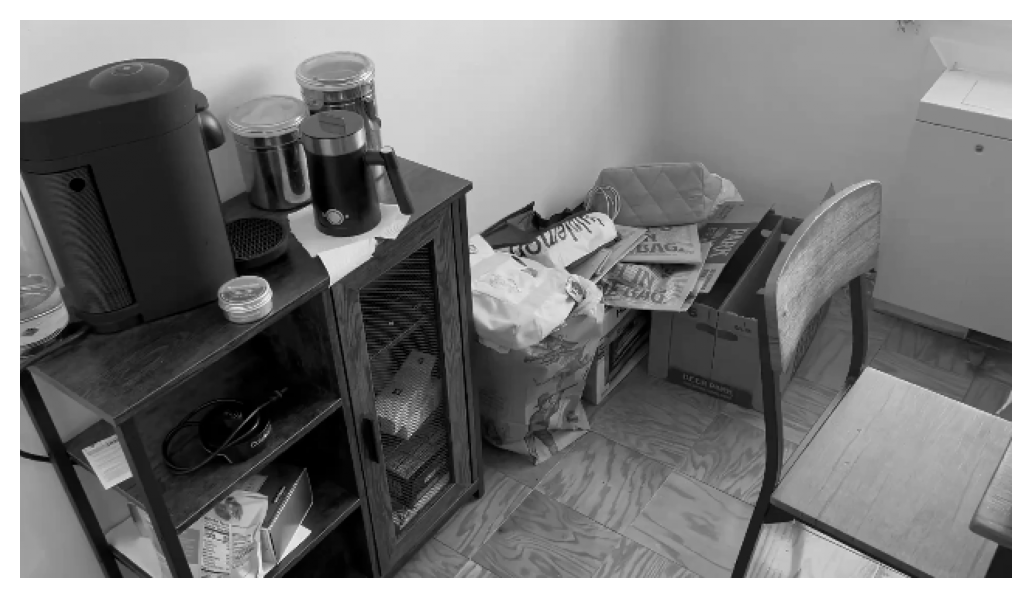

In [22]:
if N_FRAMES <= BOOTSTRAP_GAP:
    raise RuntimeError('Not enough frames for the selected BOOTSTRAP_GAP. Lower BOOTSTRAP_GAP or add more frames.')

img0 = cv2.imread(str(frames[0]), cv2.IMREAD_GRAYSCALE)
imgB = cv2.imread(str(frames[BOOTSTRAP_GAP]), cv2.IMREAD_GRAYSCALE)

if img0 is None or imgB is None:
    raise RuntimeError('Could not read the first or bootstrap image.')

height, width = img0.shape[:2]

if K_PATH.exists():
    K = np.loadtxt(K_PATH)
    print('Loaded camera matrix from', K_PATH)
else:
    # Approximate pinhole camera matrix. Replace this with calibration results for the final report when possible.
    f = 0.9 * width
    K = np.array([
        [f, 0, width / 2],
        [0, f, height / 2],
        [0, 0, 1]
    ], dtype=float)
    np.savetxt(K_PATH, K)
    print('No prob2_K.txt found. Saved approximate camera matrix to', K_PATH)

print('Image size:', width, 'x', height)
print('K =')
print(K)
cv2_imshow(img0)

In [23]:
param_bootstrap = {
    # keypoints
    'W_harris_patch' : 4,
    'kappa_harris' : 0.04,
    'N_keypoint' : 5000,
    'W_nms' : 6,

    # KLT tracking
    'W_KLT' : 6,
    'tol_KLT_bidir' : 3.0,

    # essential matrix
    'tol_E' : 3.0,
    'tol_E_RANSAC_prob' : 0.999,

    # triangulation
    'tol_TRI_mu' : 1e-2,
    'tol_TRI_rep' : 5.0
}

param = {
    # keypoints
    'W_harris_patch' : 4,
    'kappa_harris' : 0.04,
    'N_keypoint' : 800,
    'W_nms' : 6,

    # KLT tracking
    'W_KLT' : 6,
    'tol_KLT_bidir' : 3.5,

    # triangulation
    'tol_TRI_mu' : 1e-2,
    'tol_TRI_rep' : 6.0,

    # mapping
    'tol_keypoints_new' : 12
}

print('Bootstrap frame gap:', BOOTSTRAP_GAP)
print('Keypoints requested:', param['N_keypoint'])

Bootstrap frame gap: 25
Keypoints requested: 800


Number of initialized keypoints: 78
Number of initialized 3D points: 78


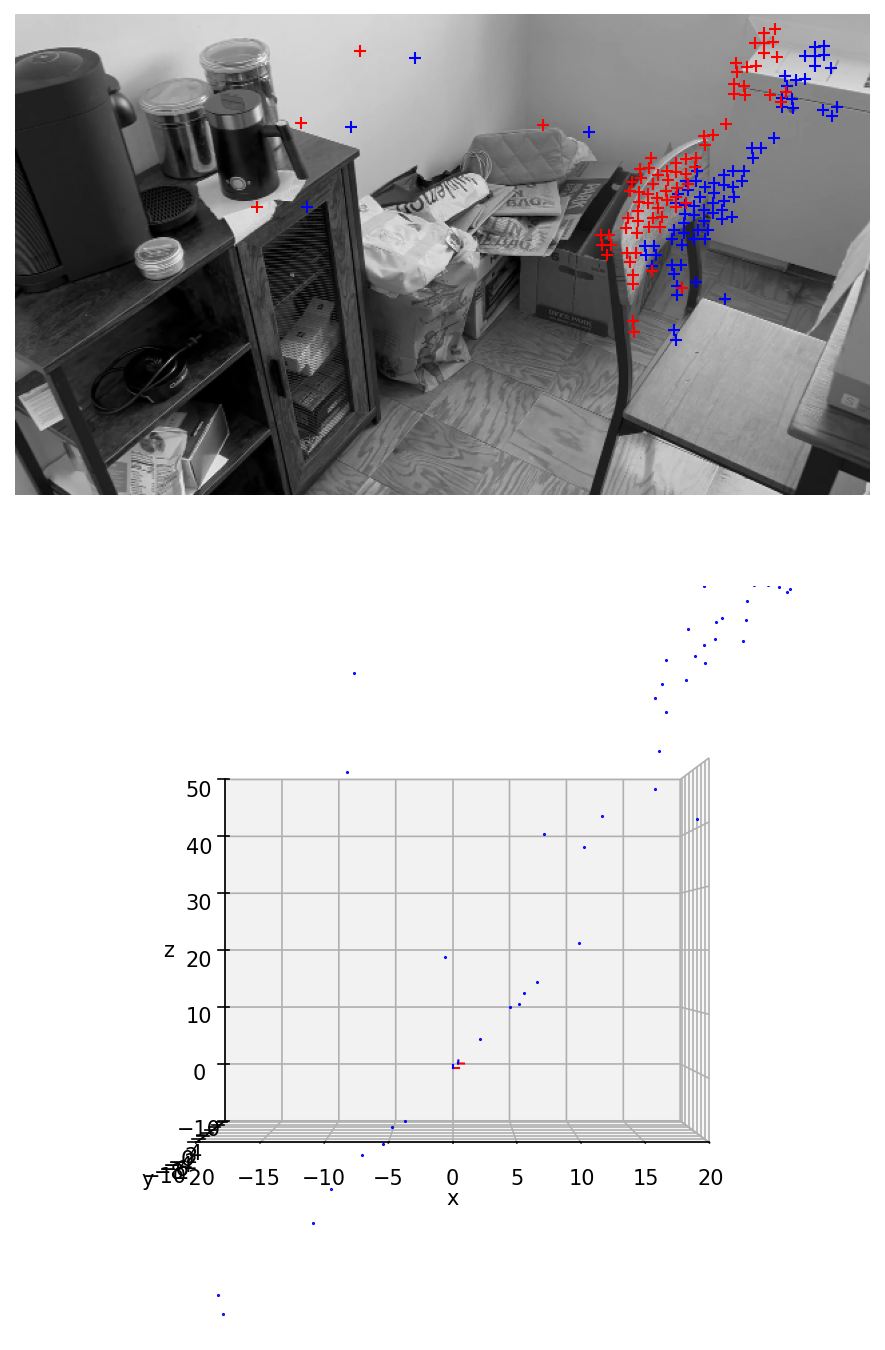

In [6]:
importlib.reload(mae6292)

keypoints0, p_W0, R1, T1 = mae6292.VO_bootstrap(
    img0,
    imgB,
    K,
    param_bootstrap,
    display=True
)

print('Number of initialized keypoints:', len(keypoints0))
print('Number of initialized 3D points:', p_W0.shape[1])

plt.savefig(OUT_DIR / 'prob2_bootstrap.png', dpi=200, bbox_inches='tight')

In [24]:
img_pre = img0
S_pre = mae6292.state(keypoints0, p_W0, [np.zeros((3, 1))])
C_pre = mae6292.candidate([], [], [], [])

# Camera centers in the world frame.
T_W = np.zeros((3, N_FRAMES))
p_W = p_W0.copy()
valid_frames = [0]

for i_frame in range(1, N_FRAMES):
    print('i_frame =', i_frame)

    img = cv2.imread(str(frames[i_frame]), cv2.IMREAD_GRAYSCALE)
    img_bgr = cv2.imread(str(frames[i_frame]), cv2.IMREAD_COLOR)

    if img is None or img_bgr is None:
        print('Skipping unreadable frame:', frames[i_frame])
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    try:
        R, T, S, C, fig = mae6292.VO_localization_mapping(
            i_frame,
            img,
            img_rgb,
            img_pre,
            S_pre,
            C_pre,
            K,
            param,
            DISPLAY_PROCESS
        )
    except Exception as error:
        print('VO failed at frame', i_frame)
        print('Error:', error)
        print('Stopping so earlier results can still be reviewed.')
        break

    img_pre, S_pre, C_pre = img, S, C

    if DISPLAY_PROCESS:
        fig.savefig(OUT_DIR / f'{i_frame:05d}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)

    T_W[:, i_frame] = (-R.T @ T).flatten()
    valid_frames.append(i_frame)

    # Keep a distinct global point cloud for the final map.
    if S.p_W.shape[1] > 0 and p_W.shape[1] > 0:
        distances = scipy.spatial.distance.cdist(S.p_W.T, p_W.T, 'euclidean')
        distinct = np.where(np.min(distances, axis=1) > 3)[0]
        if len(distinct) > 0:
            p_W = np.append(p_W, S.p_W[:, distinct], axis=1)

print('Processed frames:', len(valid_frames))
print('Saved map points:', p_W.shape[1])

i_frame = 1
i_frame = 2
S_pre= 78 , KLT_matched= 76 , PnP_inliers= 76 , S_new =  830
C_pre= 762 , KLT_matched= 757 , TRI_inliers= 754 , C_new =  7
i_frame = 3
S_pre= 830 , KLT_matched= 829 , PnP_inliers= 829 , S_new =  834
C_pre= 7 , KLT_matched= 5 , TRI_inliers= 5 , C_new =  2
i_frame = 4
S_pre= 834 , KLT_matched= 833 , PnP_inliers= 833 , S_new =  835
C_pre= 2 , KLT_matched= 2 , TRI_inliers= 2 , C_new =  1
i_frame = 5
S_pre= 835 , KLT_matched= 834 , PnP_inliers= 829 , S_new =  830
C_pre= 1 , KLT_matched= 1 , TRI_inliers= 1 , C_new =  2
i_frame = 6
S_pre= 830 , KLT_matched= 829 , PnP_inliers= 828 , S_new =  830
C_pre= 2 , KLT_matched= 2 , TRI_inliers= 2 , C_new =  3
i_frame = 7
S_pre= 830 , KLT_matched= 829 , PnP_inliers= 828 , S_new =  831
C_pre= 3 , KLT_matched= 3 , TRI_inliers= 3 , C_new =  1
i_frame = 8
S_pre= 831 , KLT_matched= 827 , PnP_inliers= 822 , S_new =  822
C_pre= 1 , KLT_matched= 1 , TRI_inliers= 0 , C_new =  3
i_frame = 9
S_pre= 822 , KLT_matched= 822 , PnP_inliers= 822 

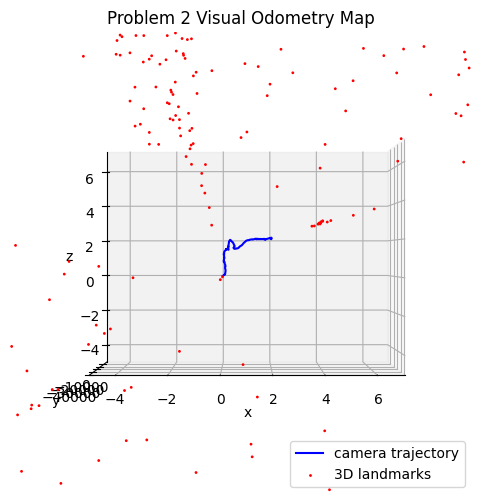

In [25]:
T_plot = T_W[:, valid_frames]

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')

ax.plot(T_plot[0, :], T_plot[1, :], T_plot[2, :], 'b', label='camera trajectory')
ax.scatter(p_W[0, :], p_W[1, :], p_W[2, :], s=1, c='r', marker='o', label='3D landmarks')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Problem 2 Visual Odometry Map')
ax.view_init(elev=0., azim=-90)
ax.legend()

# Automatic limits centered around the camera trajectory.
if T_plot.shape[1] > 1:
    ax.set_xlim(np.nanmin(T_plot[0, :]) - 5, np.nanmax(T_plot[0, :]) + 5)
    ax.set_zlim(np.nanmin(T_plot[2, :]) - 5, np.nanmax(T_plot[2, :]) + 5)

plt.savefig(OUT_DIR / 'prob2_map.png', dpi=200, bbox_inches='tight')
plt.show()

In [26]:
image_files = sorted(OUT_DIR.glob('[0-9][0-9][0-9][0-9][0-9].png'))

if len(image_files) == 0:
    raise RuntimeError('No saved process images were found. Run the VO loop first with DISPLAY_PROCESS=True.')

first = cv2.imread(str(image_files[0]))
height, width = first.shape[:2]

codec = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(OUT_DIR / 'prob2.mp4'), codec, FPS, (width, height))

for file in image_files:
    frame = cv2.imread(str(file))
    if frame is None:
        continue
    frame = cv2.resize(frame, (width, height))
    out.write(frame)

out.release()
print('Saved:', OUT_DIR / 'prob2.mp4')

Saved: prob2_output\prob2.mp4
